<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/GA_grid_maze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# GA grid maze

Coba2

Menjalankan Genetic Algorithm (Roulette Wheel)...
Generasi 1/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0220 | Stagnasi: 0
Generasi 2/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0282 | Stagnasi: 1
Generasi 3/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0306 | Stagnasi: 2
Generasi 4/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0329 | Stagnasi: 3
Generasi 5/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0297 | Stagnasi: 4
Generasi 6/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0318 | Stagnasi: 5
Generasi 7/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0304 | Stagnasi: 6
Generasi 8/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0260 | Stagnasi: 7
Generasi 9/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0261 | Stagnasi: 8
Generasi 10/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0289 | Stagnasi: 9
Generasi 11/3000 | Fitness Terbaik: 0.4867 | Langkah: 3 | Mutasi: 0.0263 | Stagnasi: 10
G

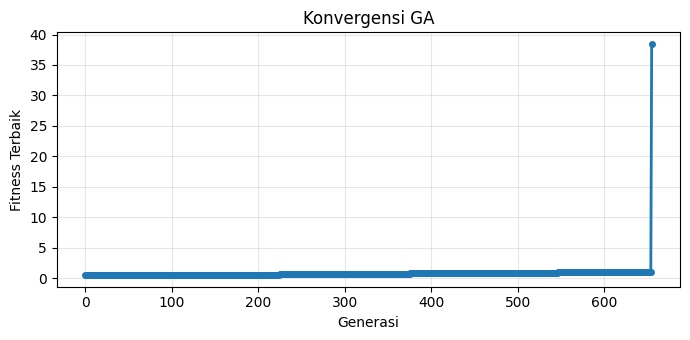

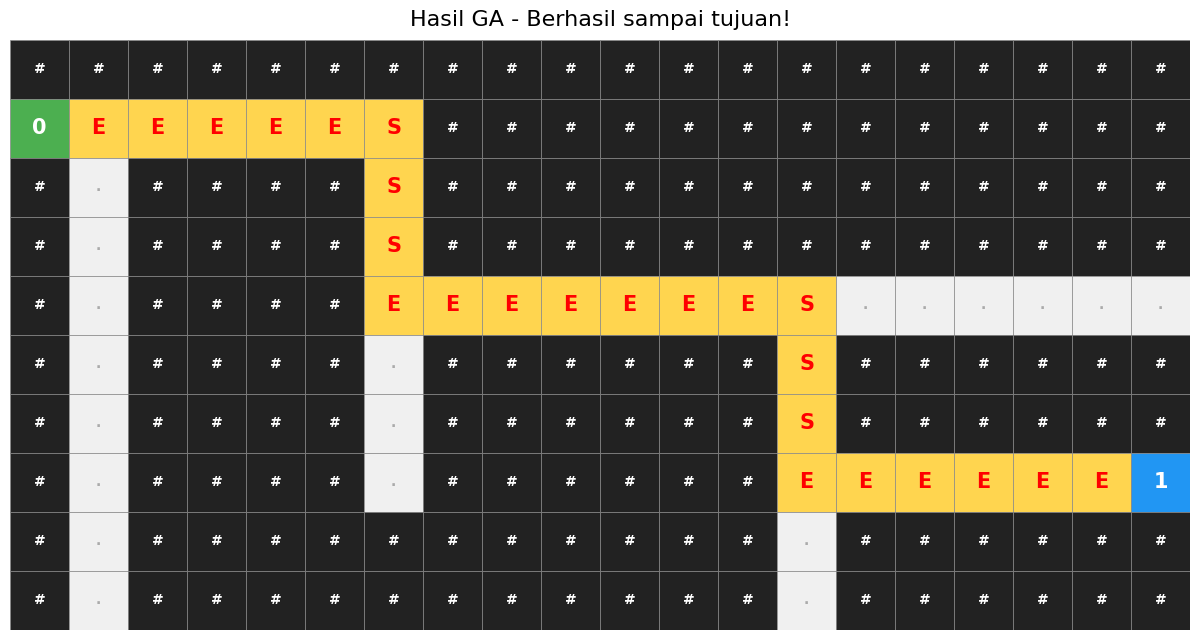

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ## 1. Definisi Grid & Arah
# 0 = Tembok, 1 = Jalan (internal)
grid_data = [
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    [0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0],
    [0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0],
    [0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,1,1,1,1,1],
    [0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
    [0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0]
]
ROWS, COLS = len(grid_data), len(grid_data[0])
START_POS = (1, 0)
END_POS   = (7, 19)

# Mapping: 0→N, 1→E, 2→S, 3→W (sesuai koordinat matriks: baris naik = S, turun = N)
MOVES = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}


# ## 2. Fungsi Evaluasi & Fitness
def evaluate_chromosome(chrom, iteration, max_iterations):
    """Simulasikan jalur agen berdasarkan kromosom.
    Return: fitness, list_path, berhasil_sampai_end"""
    r, c = START_POS
    path = [(r, c)]
    visited = {(r, c)}
    repeated_steps = 0

    for move in chrom:
        dr, dc = MOVES[move]
        nr, nc = r + dr, c + dc

        # Cek batas grid & tembok (0)
        if nr < 0 or nr >= ROWS or nc < 0 or nc >= COLS or grid_data[nr][nc] == 0:
            break

        r, c = nr, nc
        if (r, c) in visited:
            repeated_steps += 1
        else:
            visited.add((r, c))
        path.append((r, c))

        # Cek tujuan
        if (r, c) == END_POS:
            steps = len(path) - 1
            # Bonus besar untuk sampai tujuan, penalti untuk langkah berulang
            fitness = 1000.0 / (steps + 1) - repeated_steps * 0.5
            return max(fitness, 0.01), path, True

    # Jika tidak sampai tujuan
    dist_to_end = abs(r - END_POS[0]) + abs(c - END_POS[1])
    max_possible_dist = ROWS + COLS
    # Fitness berbasis kemajuan menuju tujuan + penalti langkah berulang
    progress = 1.0 - (dist_to_end / max_possible_dist)
    path_efficiency = len(visited) / max(len(path), 1)  # Rasio sel unik vs total langkah
    fitness = progress * 0.7 + path_efficiency * 0.3 - repeated_steps * 0.3
    return max(fitness, 0.001), path, False


# ## 3. Operator GA (Roulette, Crossover, Mutation)
def roulette_wheel_selection(population, fitness):
    """Seleksi berdasarkan probabilitas sebanding dengan fitness dengan sigma scaling."""
    f = np.array(fitness, dtype=np.float64)

    # Sigma scaling untuk meningkatkan selection pressure
    f_min, f_max = f.min(), f.max()
    if f_max > f_min:
        # Scale fitness ke range [0.5, 2.0] untuk meningkatkan pressure
        sigma = (f - f_min) / (f_max - f_min)
        scaled_f = 0.5 + 1.5 * sigma
    else:
        scaled_f = np.ones_like(f)

    scaled_f = np.maximum(scaled_f, 1e-6)  # Hindari pembagian nol
    probs = scaled_f / scaled_f.sum()
    cum_probs = np.cumsum(probs)

    # Stochastic universal sampling untuk diversitas lebih baik
    n_selections = 2
    start_point = np.random.random() / n_selections
    points = [start_point + i / n_selections for i in range(n_selections)]

    idx1 = np.searchsorted(cum_probs, points[0]) % len(population)
    idx2 = np.searchsorted(cum_probs, points[1]) % len(population)

    # Pastikan tidak memilih individu yang sama jika memungkinkan
    if idx1 == idx2 and len(population) > 1:
        idx2 = (idx2 + 1) % len(population)

    return population[idx1].copy(), population[idx2].copy()

def crossover(p1, p2, cx_rate=0.8):
    """Two-point crossover dengan directional bias preservation."""
    if np.random.random() < cx_rate:
        # Two-point crossover untuk menjaga building blocks
        chrom_len = len(p1)
        if chrom_len > 4:
            pt1, pt2 = sorted(np.random.choice(range(1, chrom_len-1), 2, replace=False))
            c1 = np.concatenate([p1[:pt1], p2[pt1:pt2], p1[pt2:]])
            c2 = np.concatenate([p2[:pt1], p1[pt1:pt2], p2[pt2:]])
        else:
            pt = np.random.randint(1, chrom_len)
            c1 = np.concatenate([p1[:pt], p2[pt:]])
            c2 = np.concatenate([p2[:pt], p1[pt:]])
        return c1, c2
    return p1.copy(), p2.copy()

def mutate(chrom, mut_rate=0.04):
    """Random mutation: ganti gen dengan arah acak 0-3."""
    chrom_len = len(chrom)
    n_mutations = max(1, int(mut_rate * chrom_len))

    for _ in range(n_mutations):
        idx = np.random.randint(0, chrom_len)
        chrom[idx] = np.random.randint(0, 4)

    return chrom


# ##  4. Evolution Loop
def run_ga(pop_size=80, generations=4000, chrom_len=30, cx_rate=0.9, mut_rate=0.02):
    population = np.random.randint(0, 4, size=(pop_size, chrom_len))
    best_history = []

    # Adaptive mutation rate schedule
    base_mut_rate = mut_rate
    stagnation_counter = 0
    prev_best_fit = -1
    stagnation_threshold = 10  # Generasi tanpa improvement sebelum "panic mode"

    for gen in range(generations):
        fits, paths, reached = [], [], []
        for chrom in population:
            fit, path, reach = evaluate_chromosome(chrom, gen, generations)
            fits.append(fit)
            paths.append(path)
            reached.append(reach)

        best_idx = np.argmax(fits)
        best_history.append(fits[best_idx])
        best_chrom = population[best_idx].copy()
        best_fit = fits[best_idx]

        # Detect stagnation: best fitness tidak membaik
        if best_fit > prev_best_fit * 1.01:  # Minimal 1% improvement
            stagnation_counter = 0
        else:
            stagnation_counter += 1
        prev_best_fit = max(prev_best_fit, best_fit)

        # Adaptive mutation: naik drastis kalau stuck
        if stagnation_counter > stagnation_threshold:
            # Panic mode: mutation rate tinggi untuk keluar dari local optimum
            adaptive_mut = min(base_mut_rate * 15, 0.3)
        else:
            # Normal mode: mutation rate bertahap
            fitness_array = np.array(fits)
            fitness_std = fitness_array.std()
            fitness_max = fitness_array.max()

            if fitness_max > 0:
                similarity_ratio = fitness_std / (fitness_max + 1e-6)
                adaptive_mut = base_mut_rate * (1.0 + max(0, 0.5 - similarity_ratio) * 5)
            else:
                adaptive_mut = base_mut_rate * 2.0
            adaptive_mut = min(adaptive_mut, 0.15)

        # Single elitism: only preserve the absolute best
        new_pop = [best_chrom.copy()]

        # Random injection: kalau stuck terlalu lama, inject individu random
        if stagnation_counter > stagnation_threshold * 2:
            # Inject 20% populasi random untuk reset exploration
            n_random = max(1, int(pop_size * 0.2))
            for _ in range(n_random - 1):  # -1 karena sudah ada elite
                new_pop.append(np.random.randint(0, 4, chrom_len))
            stagnation_counter = stagnation_threshold  # Reset sebagian

        while len(new_pop) < pop_size:
            p1, p2 = roulette_wheel_selection(population, fits)
            c1, c2 = crossover(p1, p2, cx_rate)
            c1 = mutate(c1, adaptive_mut)
            c2 = mutate(c2, adaptive_mut)
            new_pop.extend([c1, c2])

        population = np.array(new_pop[:pop_size])

        print(f"Generasi {gen+1}/{generations} | Fitness Terbaik: {fits[best_idx]:.4f} | Langkah: {len(paths[best_idx])-1} | Mutasi: {adaptive_mut:.4f} | Stagnasi: {stagnation_counter}")
        if reached[best_idx]:  # Jika sudah sampai tujuan, hentikan evolusi
            print("Target tercapai! Menghentikan evolusi.")
            break

    # Evaluasi final
    fits, paths, reached = [], [], []
    for chrom in population:
        fit, path, reach = evaluate_chromosome(chrom, generations, generations)
        fits.append(fit)
        paths.append(path)
        reached.append(reach)
    best_idx = np.argmax(fits)
    return paths[best_idx], reached[best_idx], best_history


# ## 5. Visualisasi Hasil
def plot_grid(path, reached):
    plt.figure(figsize=(13, 6.5))
    path_set = set(tuple(p) for p in path)

    for r in range(ROWS):
        for c in range(COLS):
            is_wall = grid_data[r][c] == 0
            is_start = (r, c) == START_POS
            is_end = (r, c) == END_POS
            on_path = (r, c) in path_set

            # Tentukan karakter & warna
            if is_start:
                char, bg, txt = '0', '#4CAF50', 'white'
            elif is_end:
                char, bg, txt = '1', '#2196F3', 'white'
            elif is_wall:
                char, bg, txt = '#', '#222222', 'white'
            elif on_path:
                # Cari arah ke langkah berikutnya
                idx = path.index((r, c))
                if idx < len(path) - 1:
                    nr, nc = path[idx+1]
                    dr, dc = nr-r, nc-c
                    char = {(-1,0):'N', (0,1):'E', (1,0):'S', (0,-1):'W'}.get((dr,dc), '?')
                else:
                    char = '*'  # Titik berhenti
                bg, txt = '#FFD54F', 'red'
            else:
                char, bg, txt = '.', '#f0f0f0', '#aaa'

            # Gambar sel
            rect = plt.Rectangle((c, ROWS-r-1), 1, 1, facecolor=bg, edgecolor='#888', lw=0.5)
            plt.gca().add_patch(rect)
            plt.text(c+0.5, ROWS-r-0.5, char, ha='center', va='center',
                     fontsize=15 if char not in ['.', '#'] else 10,
                     color=txt, fontweight='bold')

    plt.xlim(0, COLS)
    plt.ylim(0, ROWS)
    plt.gca().set_aspect('equal')
    plt.axis('off')

    status = "Berhasil sampai tujuan!" if reached else f"Berhenti setelah {len(path)-1} langkah"
    plt.title(f"Hasil GA - {status}", fontsize=16, pad=10)
    plt.tight_layout()
    plt.show()


# ##  6. Eksekusi
print("Menjalankan Genetic Algorithm (Roulette Wheel)...")
best_path, reached, history = run_ga(pop_size=80, generations=3000, chrom_len=300, cx_rate=0.9, mut_rate=0.01)
print(f"Langkah terbaik: {len(best_path)-1} | Target tercapai: {reached}")

# Plot Konvergensi
plt.figure(figsize=(7, 3.5))
plt.plot(history, marker='o', linewidth=2, markersize=4)
plt.xlabel("Generasi")
plt.ylabel("Fitness Terbaik")
plt.title("Konvergensi GA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Grid Akhir
plot_grid(best_path, reached)